<a href="https://colab.research.google.com/github/ariyan378/Statistics/blob/main/Statistics_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Applied Statistics for Machine Learning: Experimental Framework

> *"Without data, you're just another person with an opinion. Without statistics, you're just another person with a curve-fit."*

---

## 2. Experimental Architecture

| Module | Core Statistical Concepts | Direct ML Application |
| :--- | :--- | :--- |
| **I. Exploratory Analysis** | *Mean*, *Median*, *IQR*, *Variance*, *Covariance* | Feature scaling, outlier trimming, and data sanitization |
| **II. Distribution Theory** | *Gaussian*, *Binomial*, *Central Limit Theorem (CLT)* | Parametric estimation, generative modeling, error analysis |
| **III. Inferential Testing** | *p-values*, *Student's t-test*, *ANOVA*, *$\chi^2$ test* | A/B model validation, feature importance ranking |
| **IV. Data Transformation** | *Log-transform*, *Box-Cox*, *Z-score standardization* | Stabilizing gradient descent and regularizing distance metrics |

---

## 3. Core Objectives

* Construct reproducible, vectorized implementations for all fundamental summary metrics using `numpy` and `pandas`.
* Visualize complex multidimensional distributions, probability density functions (*PDFs*), and confidence intervals via `seaborn`.
* Execute end-to-end hypothesis testing protocols to make data-driven modeling decisions.
* Build automated data transformation pipelines that prevent statistical leakage prior to model training.

---

## Environment Setup

Run the following cell to initialize the numerical and statistical libraries:

```python
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot formatting for clear reporting
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("Libraries imported and visualization styles configured.")

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot formatting for clear reporting
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("Libraries imported and visualization styles configured.")

Libraries imported and visualization styles configured.


In [ ]:
import io
import pandas as pd

# Raw CSV data containing 100 rows
data = """ID,Age,Gender,Education,Weekly_Study_Hours,Annual_Income_USD,Exam_Score
1,24,Female,Bachelor,14,48000,78
2,31,Male,Master,10,72000,85
3,45,Female,High School,5,38000,62
4,22,Male,Bachelor,18,42000,88
5,38,Non-binary,Master,12,85000,81
6,29,Female,PhD,20,95000,94
7,52,Male,High School,4,41000,55
8,27,Female,Bachelor,15,53000,79
9,34,Male,Bachelor,8,61000,73
10,41,Female,Master,9,78000,82
11,23,Male,High School,12,32000,67
12,36,Female,PhD,16,105000,91
13,48,Male,Bachelor,6,64000,70
14,26,Non-binary,Bachelor,14,49000,76
15,33,Female,Master,11,74000,84
16,55,Male,High School,3,39000,58
17,30,Female,Bachelor,13,56000,80
18,42,Male,Master,7,82000,75
19,25,Female,High School,16,34000,71
20,39,Male,PhD,18,112000,96
21,28,Female,Bachelor,12,51000,77
22,46,Male,Bachelor,5,59000,68
23,35,Non-binary,Master,10,76000,83
24,21,Female,High School,15,29000,69
25,50,Male,High School,4,43000,61
26,32,Female,PhD,19,98000,92
27,27,Male,Bachelor,11,54000,74
28,44,Female,Master,8,81000,79
29,37,Male,Bachelor,9,67000,76
30,23,Female,Bachelor,17,45000,86
31,58,Male,High School,2,37000,52
32,31,Non-binary,Bachelor,13,52000,78
33,40,Female,Master,10,84000,85
34,29,Male,PhD,15,102000,89
35,24,Female,High School,14,33000,70
36,47,Male,Bachelor,6,62000,69
37,33,Female,Bachelor,12,58000,81
38,51,Male,Master,7,86000,77
39,26,Non-binary,High School,11,36000,66
40,38,Female,PhD,21,118000,97
41,22,Male,Bachelor,16,44000,82
42,43,Female,High School,5,40000,64
43,30,Male,Master,11,75000,83
44,36,Female,Bachelor,9,63000,75
45,49,Male,PhD,14,109000,90
46,25,Female,Bachelor,15,47000,80
47,56,Male,High School,3,38000,56
48,28,Non-binary,Master,12,79000,86
49,34,Female,Bachelor,10,60000,78
50,41,Male,Bachelor,7,66000,72
51,23,Female,High School,13,31000,68
52,37,Male,Master,9,83000,80
53,45,Female,PhD,17,114000,93
54,27,Male,Bachelor,14,55000,79
55,53,Female,High School,4,42000,60
56,32,Non-binary,Bachelor,11,57000,77
57,39,Male,Master,8,80000,81
58,21,Female,Bachelor,19,43000,89
59,48,Male,Bachelor,5,61000,67
60,35,Female,High School,7,39000,65
61,30,Male,PhD,16,104000,91
62,42,Female,Master,10,87000,84
63,26,Male,Bachelor,13,50000,76
64,54,Female,High School,3,40000,57
65,29,Non-binary,Bachelor,15,53000,82
66,38,Male,Master,8,77000,78
67,24,Female,Bachelor,16,46000,83
68,47,Male,PhD,13,107000,88
69,33,Female,High School,8,37000,69
70,40,Male,Bachelor,7,65000,71
71,22,Female,Bachelor,18,41000,87
72,57,Male,High School,2,36000,54
73,31,Non-binary,Master,11,81000,85
74,36,Female,PhD,18,111000,95
75,28,Male,Bachelor,12,52000,75
76,44,Female,High School,6,41000,63
77,35,Male,Bachelor,9,64000,74
78,25,Female,Master,14,73000,86
79,50,Male,PhD,12,106000,89
80,27,Female,Bachelor,13,54000,79
81,43,Male,Master,7,84000,78
82,32,Non-binary,High School,9,38000,68
83,39,Female,Bachelor,10,62000,77
84,23,Male,Bachelor,17,47000,84
85,55,Female,High School,3,39000,59
86,29,Male,Master,12,78000,82
87,46,Female,PhD,15,115000,92
88,34,Male,Bachelor,8,63000,73
89,21,Female,High School,16,30000,72
90,48,Male,Master,6,85000,76
91,37,Female,Bachelor,11,59000,80
92,26,Non-binary,Bachelor,14,48000,79
93,52,Male,High School,4,44000,62
94,30,Female,PhD,19,108000,94
95,41,Male,Bachelor,7,68000,71
96,24,Female,Bachelor,15,49000,81
97,38,Male,Master,9,82000,83
98,28,Female,High School,10,35000,67
99,45,Male,Bachelor,6,63000,70
100,33,Female,Master,13,79000,87"""

# Load into a pandas DataFrame
df = pd.read_csv(io.StringIO(data))

In [ ]:
df.head(5)

,ID,Age,Gender,Education,Weekly_Study_Hours,Annual_Income_USD,Exam_Score
0,1,24,Female,Bachelor,14,48000,78
1,2,31,Male,Master,10,72000,85
2,3,45,Female,High School,5,38000,62
3,4,22,Male,Bachelor,18,42000,88
4,5,38,Non-binary,Master,12,85000,81


In [ ]:
df['Age'].var()
#Variance

99.95999999999997

In [ ]:
df['Age'].std()
#Standard deviation

9.997999799959988

In [ ]:
#skewness
df['Age'].skew()

np.float64(0.41895482332707806)

In [ ]:
#kurtosis
df['Age'].kurtosis()

np.float64(-0.8325138655471367)

In [ ]:
np.cov(df['Age'])

array(99.96)

In [ ]:
df['Age'].corr(df['Weekly_Study_Hours'])

np.float64(-0.7375188487666517)

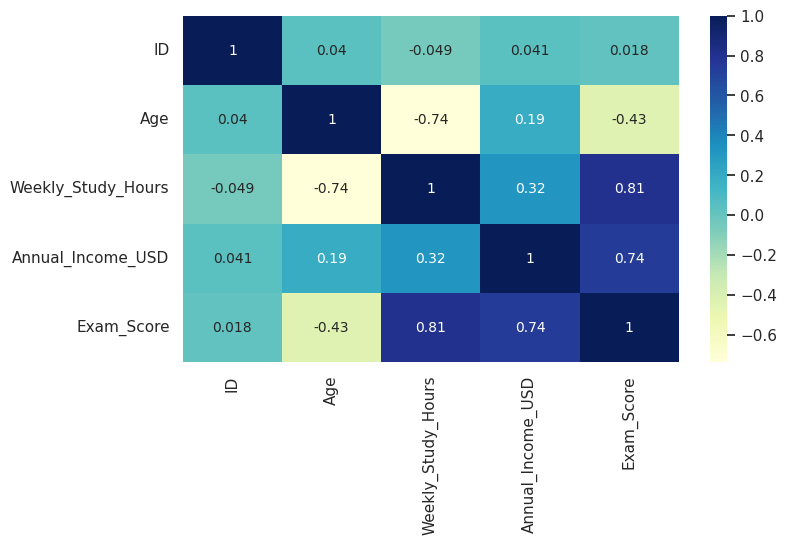

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr , annot=True, cmap="YlGnBu")
plt.show()

In [ ]:
df.head(4)

,ID,Age,Gender,Education,Weekly_Study_Hours,Annual_Income_USD,Exam_Score
0,1,24,Female,Bachelor,14,48000,78
1,2,31,Male,Master,10,72000,85
2,3,45,Female,High School,5,38000,62
3,4,22,Male,Bachelor,18,42000,88


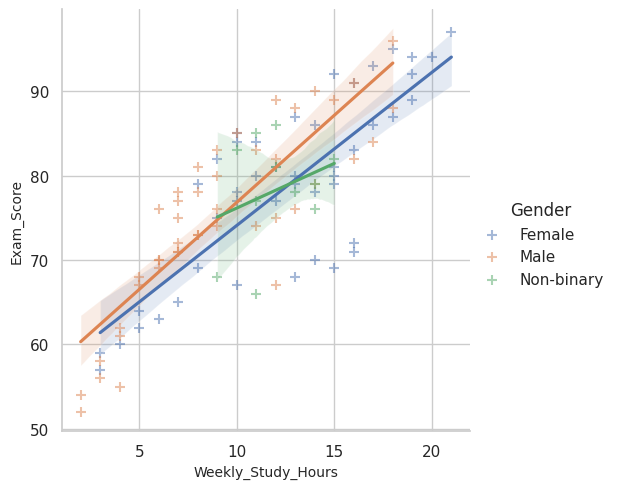

In [ ]:
sns.lmplot(data=df, x='Weekly_Study_Hours', y='Exam_Score', ci=94, hue='Gender', markers='+', scatter_kws={'s': 50, 'alpha': 0.5})
plt.show()

In [ ]:
df.head(5)

,ID,Age,Gender,Education,Weekly_Study_Hours,Annual_Income_USD,Exam_Score
0,1,24,Female,Bachelor,14,48000,78
1,2,31,Male,Master,10,72000,85
2,3,45,Female,High School,5,38000,62
3,4,22,Male,Bachelor,18,42000,88
4,5,38,Non-binary,Master,12,85000,81


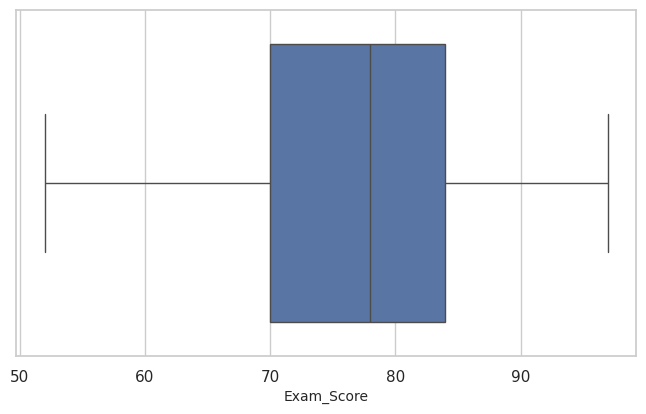

In [ ]:
sns.boxplot(data=df,x=df['Exam_Score'])
plt.show()

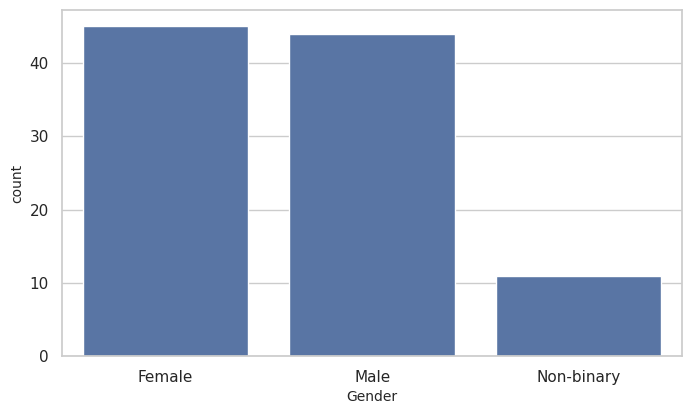

In [ ]:
sns.countplot(data=df,x =df['Gender'])
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

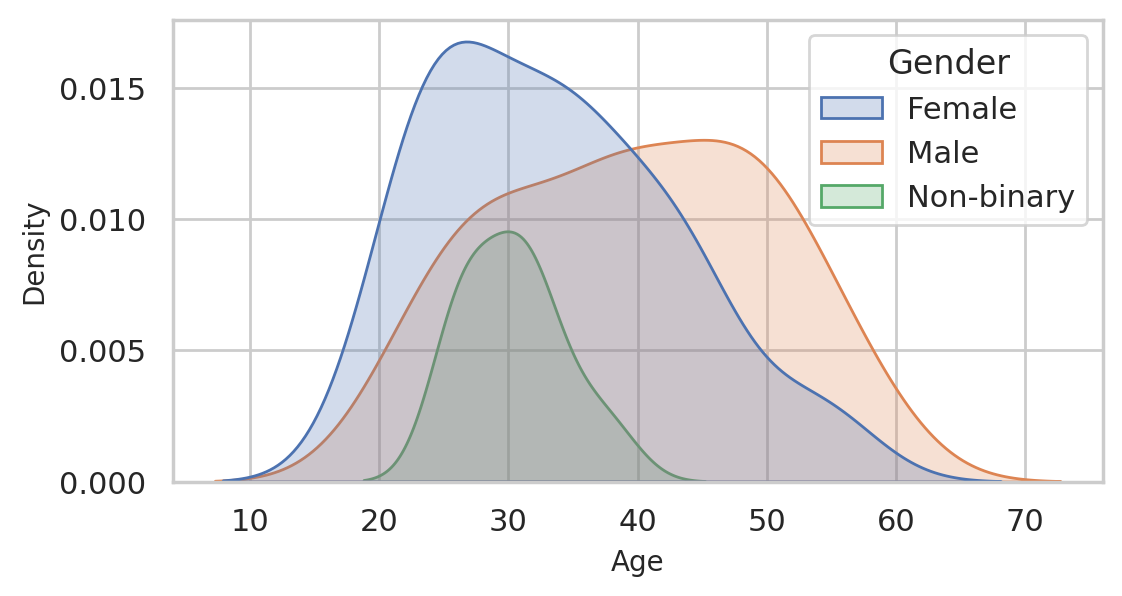

In [ ]:
plt.figure(figsize=(6, 3), dpi=200)
sns.kdeplot(data=df , x=df['Age'],fill=True, hue=df['Gender'])

In [ ]:
df.describe()

,ID,Age,Weekly_Study_Hours,Annual_Income_USD,Exam_Score
count,100.000000,100.000,100.000000,100.000000,100.000000
mean,50.500000,35.860,10.960000,63580.000000,77.000000
std,29.011492,9.998,4.629549,23820.956736,10.371873
min,1.000000,21.000,2.000000,29000.000000,52.000000
25%,25.750000,27.750,7.000000,43000.000000,70.000000
50%,50.500000,34.500,11.000000,59500.000000,78.000000
75%,75.250000,43.250,14.250000,80250.000000,84.000000
max,100.000000,58.000,21.000000,118000.000000,97.000000


Target Inventory for 97.5% Service Level: 299.0 boxes


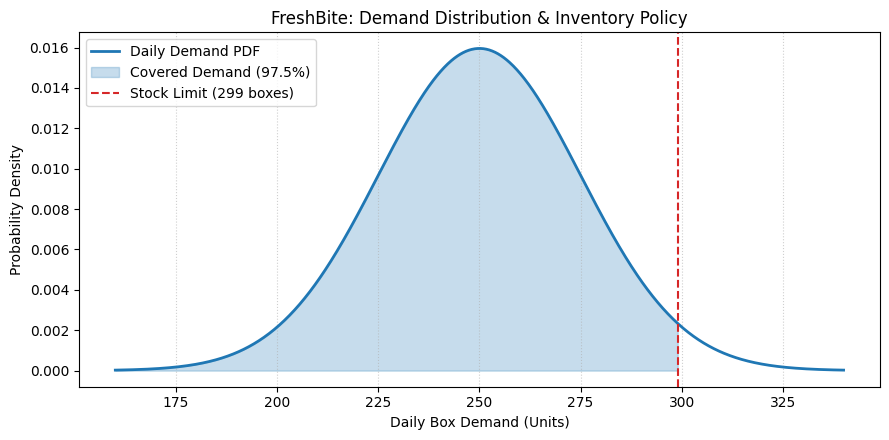

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Parameter definition
mean_demand = 250      # Average daily orders (mu)
std_demand = 25        # Standard deviation (sigma)
service_level = 0.975  # 97.5% desired fulfillment rate

# 2. Threshold calculation
inventory_target = stats.norm.ppf(service_level, loc=mean_demand, scale=std_demand)
print(f"Target Inventory for 97.5% Service Level: {inventory_target:.1f} boxes")

# 3. Visualization
x = np.linspace(160, 340, 1000)
y = stats.norm.pdf(x, loc=mean_demand, scale=std_demand)

plt.figure(figsize=(9, 4.5))
plt.plot(x, y, color="#1f77b4", lw=2, label="Daily Demand PDF")

# Shading covered demand (97.5% service area)
x_fill = np.linspace(160, inventory_target, 500)
y_fill = stats.norm.pdf(x_fill, loc=mean_demand, scale=std_demand)
plt.fill_between(x_fill, y_fill, color="#1f77b4", alpha=0.25, label="Covered Demand (97.5%)")

# Marker for the inventory policy
plt.axvline(inventory_target, color="#d62728", linestyle="--", lw=1.5,
            label=f"Stock Limit ({inventory_target:.0f} boxes)")

plt.title("FreshBite: Demand Distribution & Inventory Policy", fontsize=12)
plt.xlabel("Daily Box Demand (Units)", fontsize=10)
plt.ylabel("Probability Density", fontsize=10)
plt.legend(frameon=True)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()